In [47]:
!source myenv/Scripts/activate

'source' is not recognized as an internal or external command,
operable program or batch file.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [49]:
df = pd.read_csv('medicine_names_dataset.csv')

In [50]:
df.sample(10)

,Input,Output
2626,ritalyn,ritalin
360,aripiprazove,aripiprazole
1925,metronpdazole,metronidazole
1316,hydromorphne,hydromorphone
2171,acetaminophev,acetaminophen
834,dexijant,dexilant
2199,acetaminopqen,acetaminophen
2909,tazodone,trazodone
2315,phnetermine,phentermine
1077,elgality,emgality


# Data Cleaning

In [51]:
df.shape

(3195, 2)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3195 entries, 0 to 3194
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Input   3195 non-null   object
 1   Output  3195 non-null   object
dtypes: object(2)
memory usage: 50.1+ KB


In [53]:
df['Input'] = df['Input'].str.lower()
df['Output'] = df['Output'].str.lower()

In [54]:
df.duplicated().sum()

np.int64(1209)

In [55]:
duplicates = df[df.duplicated()]
print(duplicates)


         Input    Output
7         ctos     actos
10       actso     actos
11        ctos     actos
14        acos     actos
19       acios     actos
...        ...       ...
3186  zoplidem  zolpidem
3188  zolpdiem  zolpidem
3189   zlpidem  zolpidem
3191  zolpiedm  zolpidem
3192  ozlpidem  zolpidem

[1209 rows x 2 columns]


In [56]:
df.drop_duplicates(inplace=True)

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df.isnull().sum()

Input     0
Output    0
dtype: int64

In [59]:
df['Input'] = df['Input'].astype(str)
df['Output'] = df['Output'].astype(str)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1986 entries, 0 to 3194
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Input   1986 non-null   object
 1   Output  1986 non-null   object
dtypes: object(2)
memory usage: 46.5+ KB


In [61]:
type(df['Input'])

pandas.core.series.Series

In [62]:
df.describe(include='all')

,Input,Output
count,1986,1986
unique,1986,70
top,actds,acetaminophen
freq,1,48


# EDA

In [63]:
!pip install python-Levenshtein


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
import Levenshtein
# Unique drugs and their frequencies
unique_drugs = df['Output'].nunique()
drug_counts = df['Output'].value_counts()

print("\nNumber of Unique Drugs:", unique_drugs)
print("\nTop 5 Most Frequent Drugs:")
print(drug_counts.head())

# String length analysis
df['Input_Length'] = df['Input'].str.len()
df['Output_Length'] = df['Output'].str.len()

print("\nInput Length Stats:")
print(df['Input_Length'].describe())
print("\nOutput Length Stats:")
print(df['Output_Length'].describe())

# Optional: Levenshtein distance (if package is installed)
df['Levenshtein_Distance'] = df.apply(lambda x: Levenshtein.distance(x['Input'], x['Output']), axis=1)
print("\nLevenshtein Distance Stats:")
print(df['Levenshtein_Distance'].describe())


Number of Unique Drugs: 70

Top 5 Most Frequent Drugs:
Output
acetaminophen       48
lisdexamfetamine    37
pregabalin          35
amlodipine          32
amitriptyline       32
Name: count, dtype: int64

Input Length Stats:
count    1986.000000
mean        9.071501
std         2.223058
min         4.000000
25%         8.000000
50%         9.000000
75%        10.000000
max        16.000000
Name: Input_Length, dtype: float64

Output Length Stats:
count    1986.000000
mean        9.327291
std         2.187814
min         5.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        16.000000
Name: Output_Length, dtype: float64

Levenshtein Distance Stats:
count    1986.000000
mean        1.229104
std         0.420362
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: Levenshtein_Distance, dtype: float64


In [65]:
df['Output'].unique()

array(['actos', 'acyclovir', 'adderall', 'albuterol', 'allopurinol',
       'amitriptyline', 'amlodipine', 'amoxicillin', 'aripiprazole',
       'ativan', 'azithromycin', 'benadryl', 'celecoxib', 'cialis',
       'cipro', 'concerta', 'crestor', 'dabigatran', 'dexilant',
       'diazepam', 'divalproex', 'duloxetine', 'effexor', 'emgality',
       'flagyl', 'fluoxetine', 'gabapentin', 'hydrocodone',
       'acetaminophen', 'hydromorphone', 'hydroxyzine', 'ibuprofen',
       'levetiracetam', 'lipitor', 'lisdexamfetamine', 'lisinopril',
       'lorazepam', 'losartan', 'macrobid', 'meloxicam', 'methadone',
       'metformin', 'metronidazole', 'morphine', 'nabumetone',
       'neurontin', 'ondansetron', 'oxycodone', 'oxycontin',
       'pantoprazole', 'phentermine', 'plaquenil', 'plavix', 'prednisone',
       'pregabalin', 'prilosec', 'risperdal', 'ritalin', 'seroquel',
       'simvastatin', 'synthroid', 'toprol', 'tramadol', 'trazodone',
       'trulicity', 'valtrex', 'victoza', 'wellbutrin

In [66]:
len(df['Output'].unique())

70

In [67]:
df['Input_length'] = df['Input'].str.len()
df['Output_length'] = df['Output'].str.len()

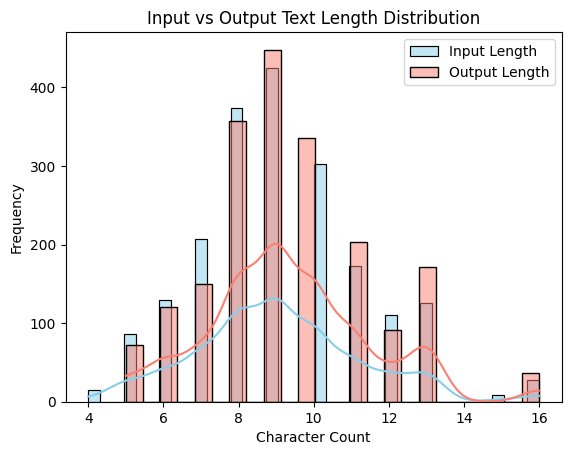

In [68]:

sns.histplot(df['Input_length'], kde=True, color='skyblue', label='Input Length')
sns.histplot(df['Output_length'], kde=True, color='salmon', label='Output Length')
plt.legend()
plt.title("Input vs Output Text Length Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

In [69]:
# ! pip install wordcloud

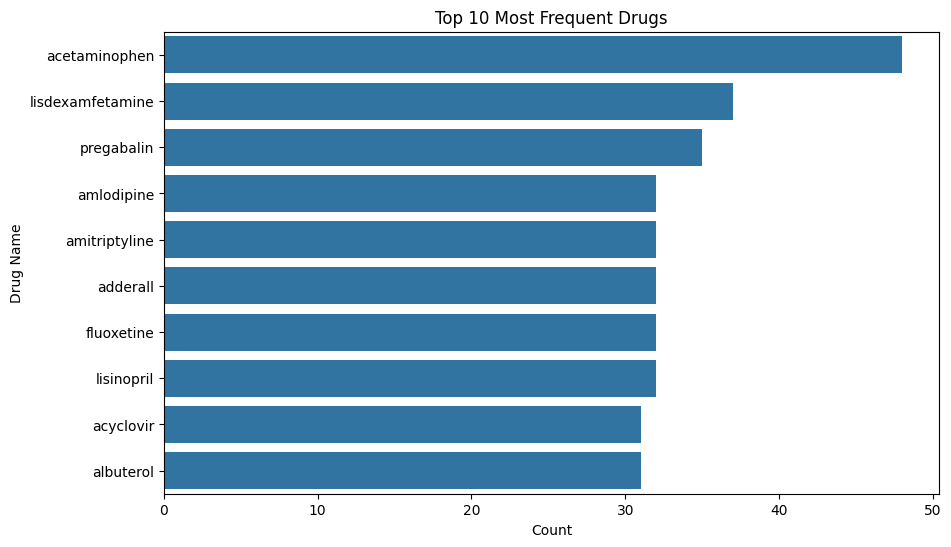

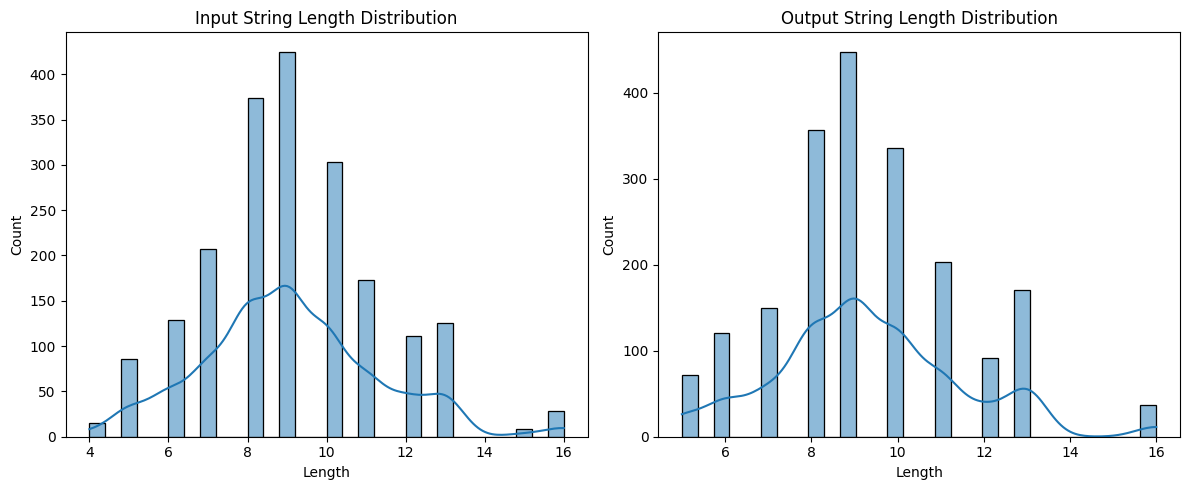

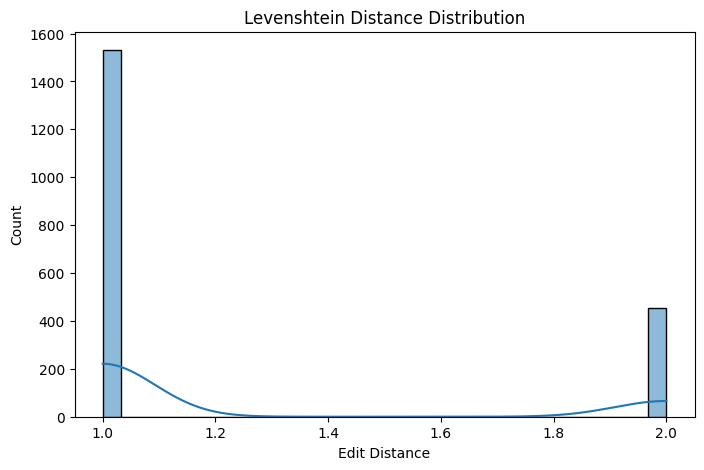

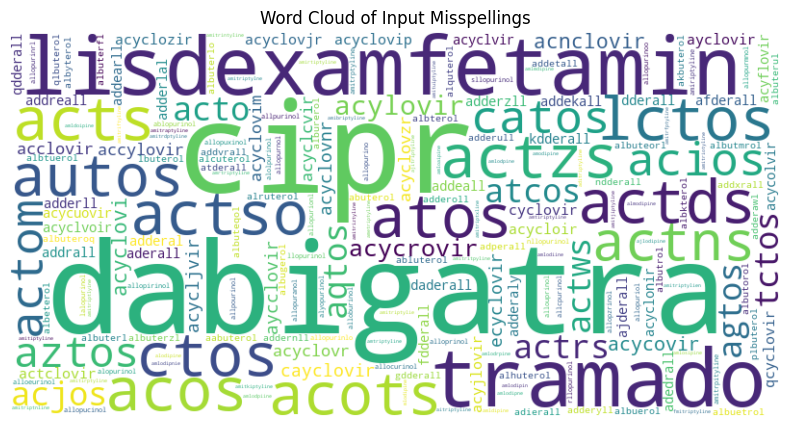

In [70]:
# Plot top 10 drugs by frequency
plt.figure(figsize=(10, 6))
sns.barplot(x=drug_counts.head(10).values, y=drug_counts.head(10).index)
plt.title('Top 10 Most Frequent Drugs')
plt.xlabel('Count')
plt.ylabel('Drug Name')
plt.show()

# Plot string length distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Input_Length'], bins=30, kde=True)
plt.title('Input String Length Distribution')
plt.xlabel('Length')
plt.subplot(1, 2, 2)
sns.histplot(df['Output_Length'], bins=30, kde=True)
plt.title('Output String Length Distribution')
plt.xlabel('Length')
plt.tight_layout()
plt.show()

# Plot Levenshtein distance (if computed)
plt.figure(figsize=(8, 5))
sns.histplot(df['Levenshtein_Distance'], bins=30, kde=True)
plt.title('Levenshtein Distance Distribution')
plt.xlabel('Edit Distance')
plt.show()

# Optional: Word cloud for Input
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['Input']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Input Misspellings')
plt.show()

In [71]:
from collections import Counter
# Perfect matches (Input == Output)
perfect_matches = df[df['Input'] == df['Output']]
print("\nNumber of Perfect Matches:", len(perfect_matches))
print("\nExamples of Perfect Matches:")
print(perfect_matches.head())

# Average Levenshtein distance per drug
avg_distance = df.groupby('Output')['Levenshtein_Distance'].mean().sort_values(ascending=False)
print("\nTop 5 Drugs by Average Levenshtein Distance:")
print(avg_distance.head())

# Short inputs (length <= 2)
short_inputs = df[df['Input_Length'] <= 2]
print("\nShort Inputs (Length <= 2):")
print(short_inputs[['Input', 'Output']].head())

# Common character substitutions (simplified, requires custom analysis)
# Example: Count frequency of characters in Input vs. Output
input_chars = Counter(''.join(df['Input']))
output_chars = Counter(''.join(df['Output']))
print("\nTop 5 Input Characters:", input_chars.most_common(5))
print("Top 5 Output Characters:", output_chars.most_common(5))


Number of Perfect Matches: 0

Examples of Perfect Matches:
Empty DataFrame
Columns: [Input, Output, Input_Length, Output_Length, Levenshtein_Distance, Input_length, Output_length]
Index: []

Top 5 Drugs by Average Levenshtein Distance:
Output
ondansetron      1.310345
hydrocodone      1.310345
risperdal        1.307692
levetiracetam    1.300000
hydromorphone    1.300000
Name: Levenshtein_Distance, dtype: float64

Short Inputs (Length <= 2):
Empty DataFrame
Columns: [Input, Output]
Index: []

Top 5 Input Characters: [('e', 1736), ('i', 1714), ('a', 1685), ('o', 1579), ('n', 1419)]
Top 5 Output Characters: [('e', 1836), ('i', 1828), ('a', 1801), ('o', 1674), ('n', 1503)]


In [72]:
df.sample(10)

,Input,Output,Input_Length,Output_Length,Levenshtein_Distance,Input_length,Output_length
1817,iethadone,methadone,9,9,1,9,9
830,dexilat,dexilant,7,8,1,7,8
1669,losaptan,losartan,8,8,1,8,8
3018,victoca,victoza,7,7,1,7,7
1590,lisinoprl,lisinopril,9,10,1,9,10
1861,metoormin,metformin,9,9,1,9,9
493,azithromcin,azithromycin,11,12,1,11,12
2013,nafumetone,nabumetone,10,10,1,10,10
55,acyclovnr,acyclovir,9,9,1,9,9
2436,predinsone,prednisone,10,10,2,10,10


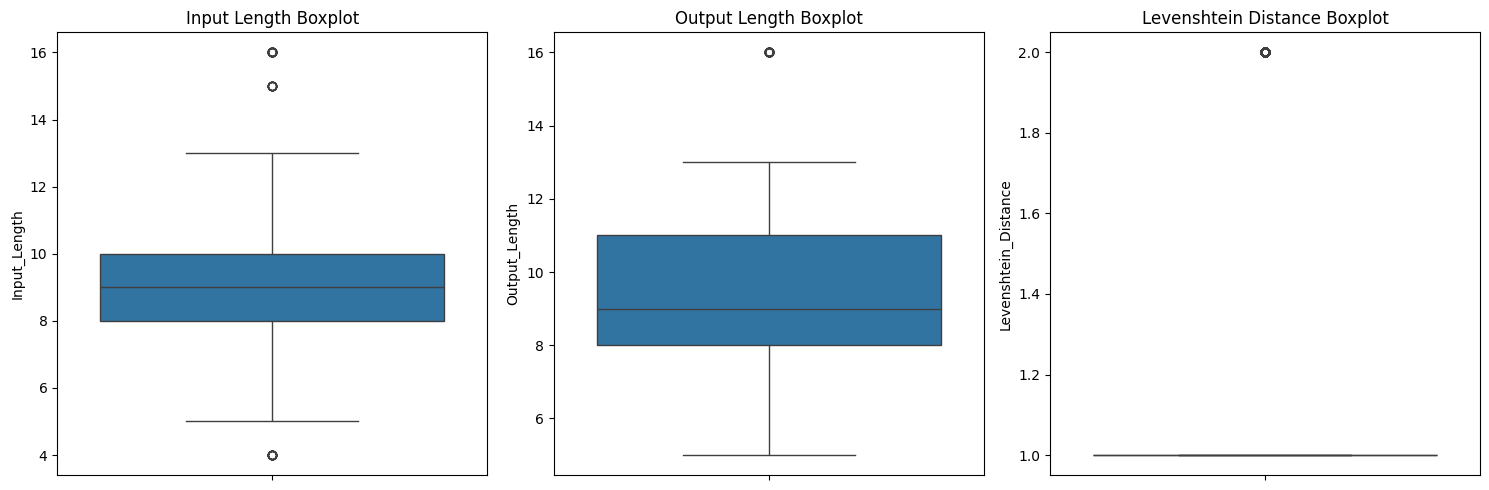

In [73]:
# Derive numerical features
df['Input_Length'] = df['Input'].str.len()
df['Output_Length'] = df['Output'].str.len()
df['Levenshtein_Distance'] = df.apply(lambda x: Levenshtein.distance(x['Input'], x['Output']), axis=1)

# Visualize boxplots
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Input_Length'])
plt.title('Input Length Boxplot')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Output_Length'])
plt.title('Output Length Boxplot')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Levenshtein_Distance'])
plt.title('Levenshtein Distance Boxplot')
plt.tight_layout()
plt.show()


In [74]:
df.head()

,Input,Output,Input_Length,Output_Length,Levenshtein_Distance,Input_length,Output_length
0,actds,actos,5,5,1,5,5
1,actzs,actos,5,5,1,5,5
2,ctos,actos,4,5,1,4,5
3,actso,actos,5,5,2,5,5
4,acts,actos,4,5,1,4,5


In [75]:
df['Tokenized_Input'] = df['Input'].apply(lambda x: list(x))
df['Tokenized_Output'] = df['Output'].apply(lambda x: list(x))

In [76]:
df.head()

,Input,Output,Input_Length,Output_Length,Levenshtein_Distance,Input_length,Output_length,Tokenized_Input,Tokenized_Output
0,actds,actos,5,5,1,5,5,"[a, c, t, d, s]","[a, c, t, o, s]"
1,actzs,actos,5,5,1,5,5,"[a, c, t, z, s]","[a, c, t, o, s]"
2,ctos,actos,4,5,1,4,5,"[c, t, o, s]","[a, c, t, o, s]"
3,actso,actos,5,5,2,5,5,"[a, c, t, s, o]","[a, c, t, o, s]"
4,acts,actos,4,5,1,4,5,"[a, c, t, s]","[a, c, t, o, s]"


In [77]:
df.shape

(1986, 9)

In [78]:
df2 = df[['Tokenized_Input','Tokenized_Output']]

In [79]:
df2.sample(10)

,Tokenized_Input,Tokenized_Output
1073,"[e, m, g, a, l, i, j, y]","[e, m, g, a, l, i, t, y]"
295,"[a, m, l, o, d, i, y, i, n, e]","[a, m, l, o, d, i, p, i, n, e]"
2003,"[n, a, h, u, m, e, t, o, n, e]","[n, a, b, u, m, e, t, o, n, e]"
520,"[e, b, n, a, d, r, y, l]","[b, e, n, a, d, r, y, l]"
552,"[c, e, e, c, o, x, i, b]","[c, e, l, e, c, o, x, i, b]"
2595,"[r, i, s, p, e, r, f, a, l]","[r, i, s, p, e, r, d, a, l]"
975,"[d, u, l, o, x, r, t, i, n, e]","[d, u, l, o, x, e, t, i, n, e]"
286,"[m, l, o, d, i, p, i, n, e]","[a, m, l, o, d, i, p, i, n, e]"
1453,"[l, e, v, e, i, t, r, a, c, e, t, a, m]","[l, e, v, e, t, i, r, a, c, e, t, a, m]"
2521,"[p, r, i, l, o, e, s, c]","[p, r, i, l, o, s, e, c]"


In [80]:
df2.head()

,Tokenized_Input,Tokenized_Output
0,"[a, c, t, d, s]","[a, c, t, o, s]"
1,"[a, c, t, z, s]","[a, c, t, o, s]"
2,"[c, t, o, s]","[a, c, t, o, s]"
3,"[a, c, t, s, o]","[a, c, t, o, s]"
4,"[a, c, t, s]","[a, c, t, o, s]"


In [81]:
df2.sample(10)

,Tokenized_Input,Tokenized_Output
1861,"[m, e, t, o, o, r, m, i, n]","[m, e, t, f, o, r, m, i, n]"
1857,"[m, t, e, f, o, r, m, i, n]","[m, e, t, f, o, r, m, i, n]"
2712,"[s, i, m, v, a, s, a, t, i, n]","[s, i, m, v, a, s, t, a, t, i, n]"
2612,"[r, i, t, a, l, i, j]","[r, i, t, a, l, i, n]"
3111,"[x, a, a, n, x]","[x, a, n, a, x]"
628,"[c, i, l, i, s]","[c, i, a, l, i, s]"
390,"[a, r, i, i, p, r, a, z, o, l, e]","[a, r, i, p, i, p, r, a, z, o, l, e]"
623,"[c, i, a, l, i, w]","[c, i, a, l, i, s]"
1947,"[m, o, r, p, h, i, c, e]","[m, o, r, p, h, i, n, e]"
2242,"[i, x, y, c, o, n, t, i, n]","[o, x, y, c, o, n, t, i, n]"


In [82]:
# Create vocabulary
all_tokens = set(['<PAD>', '<EOS>'])  # Initialize with special tokens
for seq in df['Tokenized_Input']:
    all_tokens.update(seq)
for seq in df['Tokenized_Output']:
    all_tokens.update(seq)
token_to_idx = {token: idx for idx, token in enumerate(sorted(all_tokens))}
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

In [83]:
# Step 2: Convert tokens to indices
X = [[token_to_idx[token] for token in seq] for seq in df2['Tokenized_Input']]
y = [[token_to_idx[token] for token in seq] for seq in df2['Tokenized_Output']]

In [84]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 3: Pad sequences
max_len = max(max(len(seq) for seq in X), max(len(seq) for seq in y))
X_padded = pad_sequences(X, maxlen=max_len, padding='post', value=token_to_idx['<PAD>'])
y_padded = pad_sequences(y, maxlen=max_len, padding='post', value=token_to_idx['<PAD>'])

In [85]:
max_len

16

In [86]:
from tensorflow.keras.utils import to_categorical

# Step 4: Convert output to one-hot encoding
vocab_size = len(token_to_idx)
y_one_hot = to_categorical(y_padded, num_classes=vocab_size)

In [87]:
from sklearn.model_selection import train_test_split

# Step 5: Split data
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_one_hot, test_size=0.2, random_state=42, shuffle=True)

In [88]:
# ! pip install --upgrade tensorflow

In [89]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [90]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, TimeDistributed, Dense, Bidirectional, GRU
from tensorflow.keras.optimizers import Adam

embedding_dim = 128
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    LSTM(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
    TimeDistributed(Dense(vocab_size, activation='softmax'))
])

In [91]:
# Step 7: Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [92]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

# Define model checkpoint callback to save the best model
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train model with callbacks
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=2,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/10


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.5978 - loss: 1.5601
Epoch 1: val_accuracy improved from None to 0.85961, saving model to best_model.keras
794/794 ━━━━━━━━━━━━━━━━━━━━ 625s 787ms/step - accuracy: 0.7284 - loss: 1.0676 - val_accuracy: 0.8596 - val_loss: 0.5664
Epoch 2/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8484 - loss: 0.5604
Epoch 2: val_accuracy improved from 0.85961 to 0.86385, saving model to best_model.keras
794/794 ━━━━━━━━━━━━━━━━━━━━ 4379s 6s/step - accuracy: 0.8520 - loss: 0.5373 - val_accuracy: 0.8639 - val_loss: 0.4728
Epoch 3/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 850ms/step - accuracy: 0.8608 - loss: 0.4542
Epoch 3: val_accuracy improved from 0.86385 to 0.87610, saving model to best_model.keras
794/794 ━━━━━━━━━━━━━━━━━━━━ 747s 941ms/step - accuracy: 0.8622 - loss: 0.4462 - val_accuracy: 0.8761 - val_loss: 0.3982
Epoch 4/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.8791 - loss: 0.3723
Epoch 4: val_accuracy improved from 0

In [95]:
# ===== SAVE FILES HERE =====

# Save model
model.save("Word_Reconstruct_LSTM.keras")



In [96]:
import json

# Save token → index
with open('token_to_idx.json', 'w') as f:
    json.dump(token_to_idx, f, ensure_ascii=False, indent=2)

# Save index → token
with open('idx_to_token.json', 'w') as f:
    json.dump(idx_to_token, f, ensure_ascii=False, indent=2)

In [97]:
from tensorflow.keras.models import load_model
model = load_model("Word_Reconstruct_LSTM.keras")

In [103]:
def predict_sequence(input_seq):
    # Convert input sequence to indices
    input_indices = [token_to_idx.get(token, token_to_idx['<PAD>']) for token in input_seq]
    input_padded = pad_sequences([input_indices], maxlen=max_len, padding='post', value=token_to_idx['<PAD>'])

    # Predict
    pred = model.predict(input_padded, verbose=0)
    pred_indices = np.argmax(pred, axis=-1)[0]

    # Convert indices back to tokens, stopping at <EOS> or <PAD>
    pred_tokens = []
    for idx in pred_indices:
        if idx == token_to_idx['<PAD>'] or idx == token_to_idx['<EOS>']:
            break
        pred_tokens.append(idx_to_token[idx])

    return pred_tokens

# Test multiple examples
test_cases = [
    {
        'input': list('zolpdiem'),  # Damaged version of 'panadol'
        'expected': list('zolpidem')
    },
   
    {
        'input': list('amlodipne'),  # Damaged version of 'amlodipine'
        'expected': list('amlodipine')
    },
    {
        'input': list('hydrcodone'),  # Damaged version of 'hydrocodone'
        'expected': list('hydrocodone')
    },
    {
        'input': list('morphing'),  # Damaged version of 'nuberol forte'
        'expected': list('morphine')
    }
]
# Run predictions
for i, test_case in enumerate(test_cases, 1):
    predicted_output = predict_sequence(test_case['input'])
    print(f"Test Case {i}:")
    print(f"Input: {''.join(test_case['input'])}")
    print(f"Predicted Output: {''.join(predicted_output)}")
    print(f"Expected Output: {''.join(test_case['expected'])}")
    print()

Test Case 1:
Input: zolpdiem
Predicted Output: zolpidem
Expected Output: zolpidem

Test Case 2:
Input: amlodipne
Predicted Output: amlodipine
Expected Output: amlodipine

Test Case 3:
Input: hydrcodone
Predicted Output: hydrocodone
Expected Output: hydrocodone

Test Case 4:
Input: morphing
Predicted Output: morphine
Expected Output: morphine



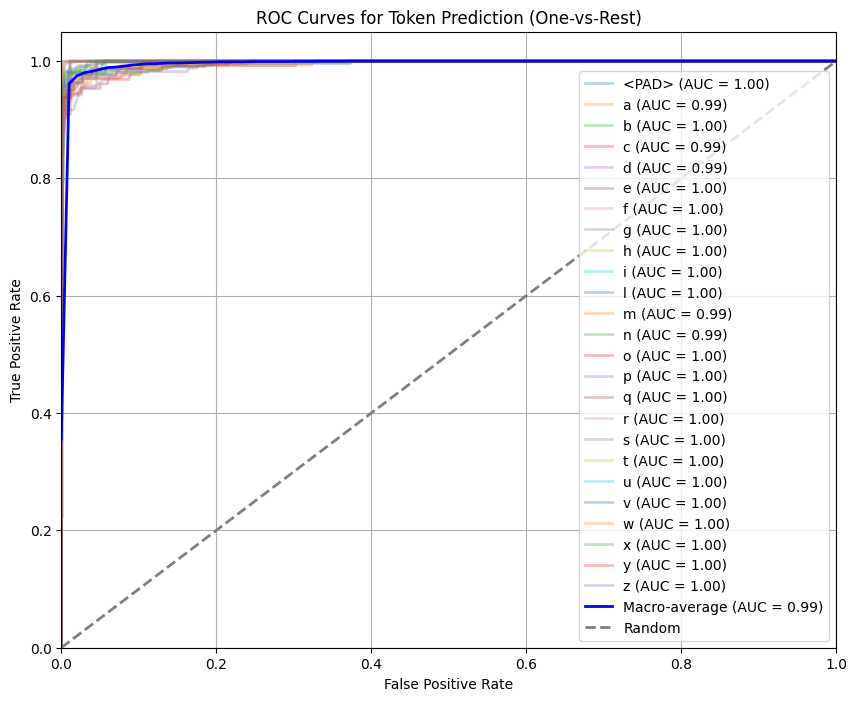

In [104]:
from sklearn.metrics import roc_curve, auc
# ROC curve plotting
def plot_roc_curve(X_test, y_test, model, token_to_idx, idx_to_token):
    # Predict probabilities
    y_pred = model.predict(X_test, verbose=0)
    y_true = np.argmax(y_test, axis=-1)  # Convert one-hot encoded y_test to class indices

    # Get vocab_size from token_to_idx or idx_to_token
    vocab_size = len(token_to_idx)

    # Flatten predictions and true labels
    y_pred_flat = y_pred.reshape(-1, vocab_size)
    y_true_flat = y_true.reshape(-1)
    y_true_one_hot = to_categorical(y_true_flat, num_classes=vocab_size)

    plt.figure(figsize=(10, 8))
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    # Plot ROC curve for each class
    for i in range(vocab_size):
        if i in y_true_flat:  # Check if class is present in true labels
            fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_pred_flat[:, i])
            roc_auc = auc(fpr, tpr)
            aucs.append(roc_auc)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            plt.plot(fpr, tpr, lw=2, alpha=0.3, label=f'{idx_to_token.get(i, f"Class {i}")} (AUC = {roc_auc:.2f})')

    # Plot macro-average ROC curve if there are valid classes
    if tprs:
        mean_tpr = np.mean(tprs, axis=0)
        mean_auc = auc(mean_fpr, mean_tpr)
        plt.plot(mean_fpr, mean_tpr, color='b', lw=2, label=f'Macro-average (AUC = {mean_auc:.2f})')

    # Plot diagonal line for random guessing
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Token Prediction (One-vs-Rest)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()  # Display the plot instead of saving

# Plot ROC curve
plot_roc_curve(X_test, y_test, model, token_to_idx, idx_to_token)

In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Assuming model, X_test, and y_test are defined from your previous code
# Predict on test set
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=-1)  # Convert predicted probabilities to class indices
y_true_classes = np.argmax(y_test, axis=-1)  # Convert one-hot encoded y_test to class indices

# Flatten the arrays for metric calculations
y_pred_flat = y_pred_classes.reshape(-1)
y_true_flat = y_true_classes.reshape(-1)

# Compute metrics
accuracy = accuracy_score(y_true_flat, y_pred_flat)
precision = precision_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)
recall = recall_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)

# Print metrics
print(f"Testing Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")

Testing Accuracy: 0.9476
Precision (Macro): 0.9155
Recall (Macro): 0.9101
F1-Score (Macro): 0.9121


In [105]:
import numpy as np
from Levenshtein import distance as levenshtein_distance

def compute_cer(y_true, y_pred, idx_to_token):
    """
    Compute Character Error Rate (CER) for predicted and true token sequences.

    Args:
        y_true: True labels (numpy array of shape (samples, timesteps) with token indices)
        y_pred: Predicted labels (numpy array of shape (samples, timesteps) with token indices)
        idx_to_token: Dictionary mapping token indices to characters/tokens

    Returns:
        cer: Character Error Rate (float)
    """
    total_distance = 0
    total_length = 0

    for true_seq, pred_seq in zip(y_true, y_pred):
        # Convert token indices to character sequences
        true_chars = ''.join([idx_to_token.get(idx, '') for idx in true_seq if idx in idx_to_token])
        pred_chars = ''.join([idx_to_token.get(idx, '') for idx in pred_seq if idx in idx_to_token])

        # Compute Levenshtein distance
        dist = levenshtein_distance(true_chars, pred_chars)
        total_distance += dist
        total_length += len(true_chars)

    # Calculate CER (avoid division by zero)
    cer = total_distance / total_length if total_length > 0 else 0
    return cer

# Assuming model, X_test, y_test, and idx_to_token are defined from your previous code
# Predict on test set
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=-1)  # Convert predicted probabilities to token indices
y_true_classes = np.argmax(y_test, axis=-1)  # Convert one-hot encoded y_test to token indices

# Compute CER
cer = compute_cer(y_true_classes, y_pred_classes, idx_to_token)

# Print CER
print(f"Character Error Rate (CER): {cer:.4f} ({cer * 100:.2f}%)")

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Character Error Rate (CER): 0.0201 (2.01%)


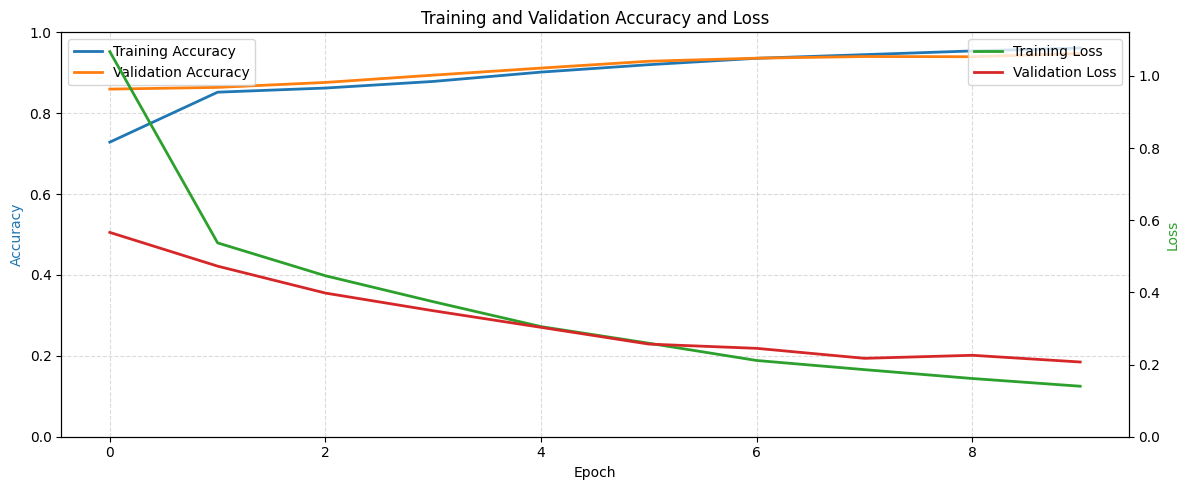

In [107]:
# Create the plot
plt.figure(figsize=(12, 5))

# Plot accuracy (training and validation) on the left y-axis
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)

# Create a second y-axis for loss
ax = plt.gca()  # Get current axis
ax_loss = ax.twinx()  # Create twin axis for loss
ax_loss.plot(history.history['loss'], label='Training Loss', color='#2ca02c', linewidth=2)
ax_loss.plot(history.history['val_loss'], label='Validation Loss', color='#d62728', linewidth=2)

# Set labels and titles
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy', color='#1f77b4')
ax_loss.set_ylabel('Loss', color='#2ca02c')
plt.title('Training and Validation Accuracy and Loss')

# Set axis limits (assuming accuracy and loss are normalized between 0 and 1)
ax.set_ylim(0, 1)
ax_loss.set_ylim(0, max(max(history.history['loss']), max(history.history['val_loss'])) * 1.05)

# Add legends
ax.legend(loc='upper left')
ax_loss.legend(loc='upper right')

# Add grid
ax.grid(True, color='#cccccc', linestyle='--', alpha=0.7)
ax_loss.grid(False)  # Avoid overlapping grid lines

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

In [108]:
import pickle

# Save history as a pickle file
with open('Simple_LSTM_History.pkl', 'wb') as file:
    pickle.dump(history.history, file)
